In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
path=os.path.dirname(os.getcwd())

**Postprocess plots**

In [76]:
# report=pd.read_csv('C:/Users/zhouq/Documents/optimal_transport/report_postprocess_baryrace.csv')
pa='sex'
report=pd.read_csv(path+'/data/report_postprocess_'+pa+'_0.05.csv')
performance=list(report.columns)[:-1]
# methods=['origin','baseline','partial repair2','partial repair3','barycentre'] #,'partial repair4','barycentre'
methods=['origin','unconstrained','barycentre','ROC','partial_0.001']
#list(set(report['method']))
colors=['#5f0f40','#9a031e','red','#FF8811','#F4D06F'] #' dark purple
pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])
pivot

C:\Users\zhouq\AppData\Local\Temp\ipykernel_2864\3415330968.py:9: FutureWarning: The provided callable <function mean at 0x000001A062A28F70> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])
C:\Users\zhouq\AppData\Local\Temp\ipykernel_2864\3415330968.py:9: FutureWarning: The provided callable <function std at 0x000001A062A2D0D0> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  pivot=pd.pivot_table(report,index=['method'],values=performance,aggfunc=[np.mean,np.std])


mean                                                   std  \
                     DI TV distance  f1 macro  f1 micro f1 weighted        DI   
method                                                                          
ROC            0.959077    0.208544  0.688473  0.740293    0.752807  0.076727   
barycentre     0.902651    0.000912  0.513989  0.610176    0.625717  0.136121   
origin         0.425568    0.208544  0.683370  0.817715    0.790140  0.019025   
partial_0.001  0.738035    0.012232  0.663367  0.786114    0.768600  0.029927   
unconstrained  0.425568    0.208544  0.683370  0.817715    0.790140  0.019025   

                                                           
              TV distance  f1 macro  f1 micro f1 weighted  
method                                                     
ROC              0.004108  0.024436  0.042917    0.033814  
barycentre       0.000764  0.016794  0.021259    0.016982  
origin           0.004108  0.003683  0.002330    0.003106  
partial_0.001    0.000094  0.003535  0.002604    0.003107  
unconstrained    0.004108  0.003683  0.002330    0.003106

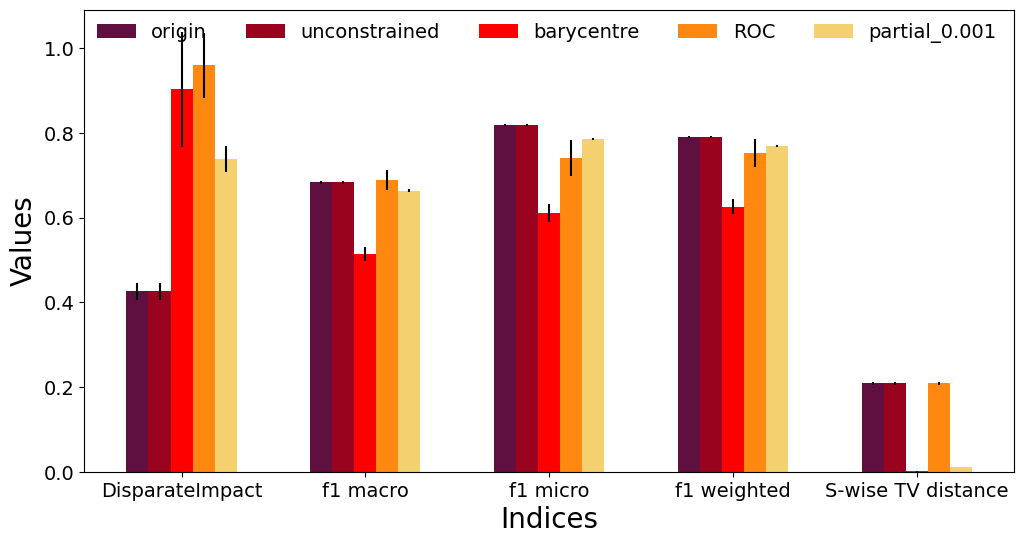

In [77]:
ind=np.arange(len(performance))
width = 0.12

fig, ax1 = plt.subplots(figsize=(12,6))

i=0
for m in methods:
    sub=[pivot[('mean',p)][m] for p in performance]
    err=[pivot[('std',p)][m] for p in performance]
    ax1.bar(ind+width*i,sub,width,yerr=err,color=colors[i],label=m)
    i+=1
# ['Origin','Baseline',r'$1e^{-2}$-repair',r'$1e^{-3}$-repair','Barycentre']
ax1.legend(methods,fontsize=14,
            framealpha=0.2,bbox_to_anchor=(1.0,1.01),ncol=5,frameon=False)
ax1.set_xlabel('Indices', fontsize=20)
ax1.set_ylabel('Values', fontsize=20)

ax1.set_xticks(ind+width*2)
ax1.set_xticklabels(['DisparateImpact']+[i for i in performance[1:-1]]+['S-wise TV distance'], fontsize=14)
ax1.tick_params(axis='y', which='major', labelsize=14)

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.savefig(path+"/plots/adult_higher_"+pa+".pdf",bbox_inches='tight')